<a href="https://colab.research.google.com/github/BarshaPanthi7/Danphe_task_Barsha/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## WESAD Dataset

In [ ]:
from google.colab import files

# Upload kaggle.json
files.upload()

In [7]:
import os
import shutil

# Creating  Kaggle configuration directory
os.makedirs("/root/.config/kaggle", exist_ok=True)

# Moving the Kaggle API key to the required location
shutil.move(
    "/content/kaggle.json",
    "/root/.config/kaggle/kaggle.json"
)

# Set secure permissions
os.chmod(
    "/root/.config/kaggle/kaggle.json",
    0o600
)

print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [5]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 4.1 MB/s eta 0:00:00


In [6]:
!kaggle --version

Kaggle CLI 2.2.4


In [8]:
# Searching for the WESAD dataset
!kaggle datasets list -s wesad

ref                                                    title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  --------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
mohamedasem318/wesad-full-dataset                      WESAD - Full Dataset                          2612994853  2025-04-30 22:58:23.297000           3067         27  0.9411765        
orvile/wesad-wearable-stress-affect-detection-dataset  WESAD (Wearable Stress and Affect Detection)  2612988288  2025-04-19 16:45:03.150000          13454         62  1                
qiriro/stress                                          Biometrics for stress monitoring              5623939830  2019-05-12 16:31:04.393000           7272        102  0.7058824        
amineipad/wesad-small-dataset                          Wesad Full Dataset C

In [9]:
# Checking the files available in the WESAD Kaggle dataset
!kaggle datasets files -d orvile/wesad-wearable-stress-affect-detection-dataset --page-size 200

name                                  size  creationDate                
------------------------------  ----------  --------------------------  
WESAD/S10/S10.pkl                867178991  2025-04-19 16:45:43.325000  
WESAD/S10/S10_E4_Data/ACC.csv      2041006  2025-04-19 16:47:41.175000  
WESAD/S10/S10_E4_Data/BVP.csv      2647417  2025-04-19 16:47:42.347000  
WESAD/S10/S10_E4_Data/EDA.csv       245619  2025-04-19 16:47:41.864000  
WESAD/S10/S10_E4_Data/HR.csv         42125  2025-04-19 16:47:42.325000  
WESAD/S10/S10_E4_Data/IBI.csv       108041  2025-04-19 16:47:42.330000  
WESAD/S10/S10_E4_Data/TEMP.csv      163759  2025-04-19 16:47:42.314000  
WESAD/S10/S10_E4_Data/info.txt        1544  2025-04-19 16:47:42.319000  
WESAD/S10/S10_E4_Data/tags.csv          14  2025-04-19 16:47:42.379000  
WESAD/S10/S10_quest.csv               1076  2025-04-19 16:45:28.431000  
WESAD/S10/S10_readme.txt               374  2025-04-19 16:45:28.445000  
WESAD/S10/S10_respiban.txt       234434035  2025-04

In [10]:
import kagglehub

# Download the WESAD dataset
path = kagglehub.dataset_download(
    'orvile/wesad-wearable-stress-affect-detection-dataset'
)

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'wesad-wearable-stress-affect-detection-dataset' dataset.
Dataset downloaded to: /kaggle/input/wesad-wearable-stress-affect-detection-dataset


In [11]:
import os

# Displaying the files and folders in the downloaded dataset
print("Contents of dataset:")

for item in os.listdir(path):
    print(item)

Contents of dataset:
WESAD


In [3]:
# Checking whether the dataset contains a WESAD folder
wesad_path = os.path.join(path, "WESAD")

print(os.listdir(wesad_path))

['wesad_readme.pdf', 'S13', 'S11', 'S8', 'S14', 'S4', 'S9', 'S7', 'S5', 'S15', 'S3', 'S10', 'S16', 'S17', 'S2', 'S6']


In [12]:
# Listing participant folders
participants = sorted([
    folder for folder in os.listdir(wesad_path)
    if folder.startswith("S")
])

print("Number of participants:", len(participants))
print("Participants:", participants)

Number of participants: 15
Participants: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [13]:
# Inspecting the files inside participant S2
s2_path = os.path.join(wesad_path, "S2")

print("Files inside S2:")
print(os.listdir(s2_path))

Files inside S2:
['S2.pkl', 'S2_readme.txt', 'S2_respiban.txt', 'S2_E4_Data', 'S2_quest.csv']


Each WESAD participant folder contains several files and subfolders.

For example, participant S2 contains:

- `S2.pkl` - main physiological signal and label data
- `S2_readme.txt` - participant-specific information/documentation
- `S2_respiban.txt` - information related to the RespiBAN device
- `S2_E4_Data` - Empatica E4 wrist-device data
- `S2_quest.csv` - questionnaire information

The `.pkl` file will be used for the main physiological signal and label analysis.

checking the size of each file folder

In [14]:
# Checking the size of files and folders for participant S2

for item in os.listdir(s2_path):
    item_path = os.path.join(s2_path, item)

    if os.path.isfile(item_path):
        size_mb = os.path.getsize(item_path) / (1024 ** 2)
        print(f"{item}: {size_mb:.2f} MB")
    else:
        print(f"{item}: folder")

S2.pkl: 929.94 MB
S2_readme.txt: 0.00 MB
S2_respiban.txt: 249.17 MB
S2_E4_Data: folder
S2_quest.csv: 0.00 MB


loading s2 data

In [15]:
import pickle

s2_file = os.path.join(s2_path, "S2.pkl")

with open(s2_file, "rb") as f:
    s2_data = pickle.load(f, encoding="latin1")

print("Data type:", type(s2_data))

Data type: <class 'dict'>


In [16]:
print("Available keys:")
print(s2_data.keys())

Available keys:
dict_keys(['signal', 'label', 'subject'])


inspecting participant

In [17]:
print("Subject:", s2_data['subject'])

Subject: S2


exploring the signal groups

In [18]:
print("Signal groups:")
print(s2_data['signal'].keys())

Signal groups:
dict_keys(['chest', 'wrist'])


In [19]:
# Checking the signals collected from the chest device
print("Chest signals:")
print(s2_data['signal']['chest'].keys())

Chest signals:
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [20]:
# Checking the signals collected from the wrist device
print("Wrist signals:")
print(s2_data['signal']['wrist'].keys())

Wrist signals:
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


checking signal shapes

In [22]:
# Checking the shape of each chest signal

chest = s2_data['signal']['chest']

for signal_name, signal_data in chest.items():
    print(f"{signal_name}: {signal_data.shape}")

ACC: (4255300, 3)
ECG: (4255300, 1)
EMG: (4255300, 1)
EDA: (4255300, 1)
Temp: (4255300, 1)
Resp: (4255300, 1)


In [23]:
# Checking the shape of each wrist signal

wrist = s2_data['signal']['wrist']

for signal_name, signal_data in wrist.items():
    print(f"{signal_name}: {signal_data.shape}")

ACC: (194528, 3)
BVP: (389056, 1)
EDA: (24316, 1)
TEMP: (24316, 1)


labels

In [24]:
import numpy as np

labels = s2_data['label']

print("Number of labels:", len(labels))
print("Unique labels:", np.unique(labels))

Number of labels: 4255300
Unique labels: [0 1 2 3 4 6 7]


In [25]:
# Counting the number of samples for each label

unique_labels, label_counts = np.unique(labels, return_counts=True)

for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count}")

Label 0: 2142701
Label 1: 800800
Label 2: 430500
Label 3: 253400
Label 4: 537599
Label 6: 45500
Label 7: 44800


visualizing label distribution

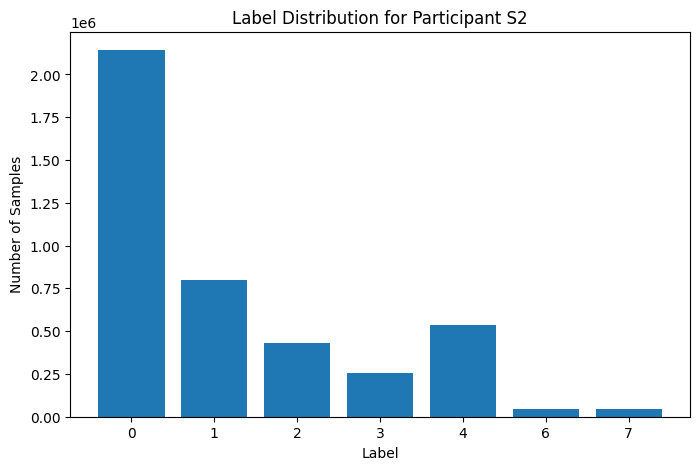

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(unique_labels.astype(str), label_counts)

plt.title("Label Distribution for Participant S2")
plt.xlabel("Label")
plt.ylabel("Number of Samples")

plt.show()

In [27]:
print(s2_data.keys())

dict_keys(['signal', 'label', 'subject'])


In [28]:
print(s2_data['signal']['chest'].keys())
print(s2_data['signal']['wrist'].keys())

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [29]:
for signal_name, signal_data in s2_data['signal']['chest'].items():
    print(signal_name, signal_data.shape)

ACC (4255300, 3)
ECG (4255300, 1)
EMG (4255300, 1)
EDA (4255300, 1)
Temp (4255300, 1)
Resp (4255300, 1)


## Signal Structure of Participant S2

The chest device provides:

- ACC - acceleration
- ECG - electrocardiogram
- EMG - muscle activity
- EDA - electrodermal activity
- Temp - temperature
- Resp - respiration

The wrist device provides:

- ACC - acceleration
- BVP - blood volume pulse
- EDA - electrodermal activity
- TEMP - temperature

 chest signals contain 4,255,300 samples.

 acceleration signal has three channels representing three axes, while the other chest signals contain one channel.

checking the labels

In [30]:
# Checking the unique labels for participant S2

labels = s2_data['label']

unique_labels, label_counts = np.unique(labels, return_counts=True)

print("Unique labels:", unique_labels)
print()

for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count:,} samples")

Unique labels: [0 1 2 3 4 6 7]

Label 0: 2,142,701 samples
Label 1: 800,800 samples
Label 2: 430,500 samples
Label 3: 253,400 samples
Label 4: 537,599 samples
Label 6: 45,500 samples
Label 7: 44,800 samples


In [31]:
# Checking the participant ID

print("Subject:", s2_data['subject'])

Subject: S2


In [33]:
import pandas as pd

# Createing a summary of label counts and percentages

label_summary = pd.DataFrame({
    'label': unique_labels,
    'count': label_counts
})

label_summary['percentage'] = (
    label_summary['count'] / label_summary['count'].sum() * 100
).round(2)

label_summary

,label,count,percentage
0,0,2142701,50.35
1,1,800800,18.82
2,2,430500,10.12
3,3,253400,5.95
4,4,537599,12.63
5,6,45500,1.07
6,7,44800,1.05


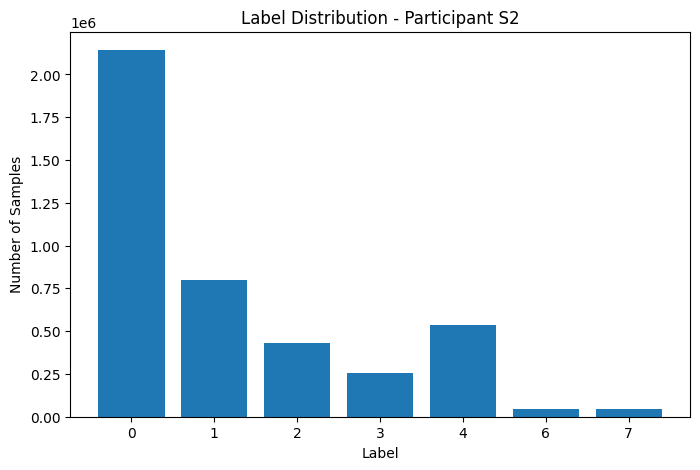

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    label_summary['label'].astype(str),
    label_summary['count']
)

plt.title('Label Distribution - Participant S2')
plt.xlabel('Label')
plt.ylabel('Number of Samples')

plt.show()

inspecting wesad documentation

In [35]:
# Reading the participant specific documentation

s2_readme = os.path.join(s2_path, "S2_readme.txt")

with open(s2_readme, "r", encoding="utf-8", errors="ignore") as f:
    readme_text = f.read()

print(readme_text)

### Personal information ###
Age: 27
Height (cm): 175
Weight (kg): 80
Gender: male
Dominant hand: right

### Study pre-requisites ###
Did you drink coffee today? NO
Did you drink coffee within the last hour? NO
Did you do any sports today? NO
Are you a smoker? NO
Did you smoke within the last hour? NO
Do you feel ill today? NO

### Additional notes ###
The RespiBAN temperature sensor was not fully attached throughout the entire duration of the study protocol.



In [36]:
print("Chest samples:", chest['ECG'].shape[0])
print("Label samples:", len(labels))

print("Match:", chest['ECG'].shape[0] == len(labels))

Chest samples: 4255300
Label samples: 4255300
Match: True


finding

### Data Consistency Check

The total number of label samples matches the number of samples in the chest physiological signals.